Model                | MAE        | RMSE       | R2 Score  
------------------------------------------------------------
Linear Regression    | 2.606      | 4.166      | 0.985     
Decision Tree        | 1.574      | 2.787      | 0.993     


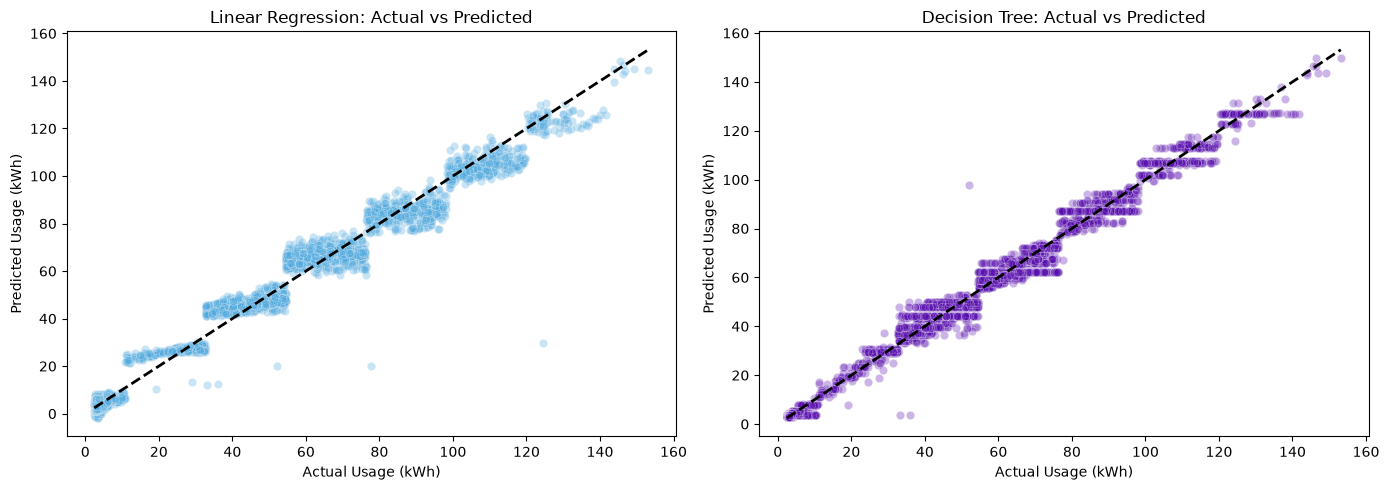

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data and replicate our engineered features from the EDA notebook
df = pd.read_csv('data/Steel_industry_data.csv')
df.columns = df.columns.str.strip()

df['date'] = pd.to_datetime(df['date'], format='mixed')
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek  # Numeric for modeling
df['month'] = df['date'].dt.month
df['is_weekend'] = df['date'].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)

epsilon = 1e-9
df['Power_Factor_Ratio'] = df['Leading_Current_Power_Factor'] / (df['Lagging_Current_Power_Factor'] + epsilon)

# 2. Select Features (X) and Target (y)
# We drop non-numeric tracking columns to keep our baseline clean
features = [
    'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh',
    'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor',
    'hour', 'day_of_week', 'month', 'is_weekend', 'Power_Factor_Ratio'
]
X = df[features]
y = df['Usage_kWh']

# 3. Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train Baseline Models
lr_model = LinearRegression()
dt_model = DecisionTreeRegressor(random_state=42, max_depth=8)  # max_depth keeps baseline from overfitting

lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)

# 5. Generate Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

# 6. Evaluate Performance
metrics = {
    'Linear Regression': {
        'MAE': mean_absolute_error(y_test, y_pred_lr),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        'R2': r2_score(y_test, y_pred_lr)
    },
    'Decision Tree': {
        'MAE': mean_absolute_error(y_test, y_pred_dt),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        'R2': r2_score(y_test, y_pred_dt)
    }
}

# Display results in a clean format
print(f"{'Model':<20} | {'MAE':<10} | {'RMSE':<10} | {'R2 Score':<10}")
print("-" * 60)
for model_name, model_metrics in metrics.items():
    print(f"{model_name:<20} | {model_metrics['MAE']:<10.3f} | {model_metrics['RMSE']:<10.3f} | {model_metrics['R2']:<10.3f}")

# 7. Plot Residuals comparison side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=y_test, y=y_pred_lr, ax=axes[0], alpha=0.3, color='#4ea8de')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Actual Usage (kWh)')
axes[0].set_ylabel('Predicted Usage (kWh)')

sns.scatterplot(x=y_test, y=y_pred_dt, ax=axes[1], alpha=0.3, color='#560bad')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[1].set_title('Decision Tree: Actual vs Predicted')
axes[1].set_xlabel('Actual Usage (kWh)')
axes[1].set_ylabel('Predicted Usage (kWh)')
plt.tight_layout()
plt.show()

In [2]:
print(df.columns.tolist())

['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'hour', 'day_of_week', 'month', 'is_weekend', 'Power_Factor_Ratio']


In [8]:
%whos

Variable                Type                     Data/Info
----------------------------------------------------------
DecisionTreeRegressor   ABCMeta                  <class 'sklearn.tree._cla<...>s.DecisionTreeRegressor'>
LinearRegression        ABCMeta                  <class 'sklearn.linear_mo<...>._base.LinearRegression'>
X                       DataFrame                Shape: (35040, 10)
X_test                  DataFrame                Shape: (7008, 10)
X_train                 DataFrame                Shape: (28032, 10)
axes                    ndarray                  2: 2 elems, type `object`, 16 bytes
df                      DataFrame                Shape: (35040, 16)
dt_model                DecisionTreeRegressor    DecisionTreeRegressor(max<...>depth=8, random_state=42)
epsilon                 float                    1e-09
features                list                     n=10
fig                     Figure                   Figure(1400x500)
lr_model                LinearRegres

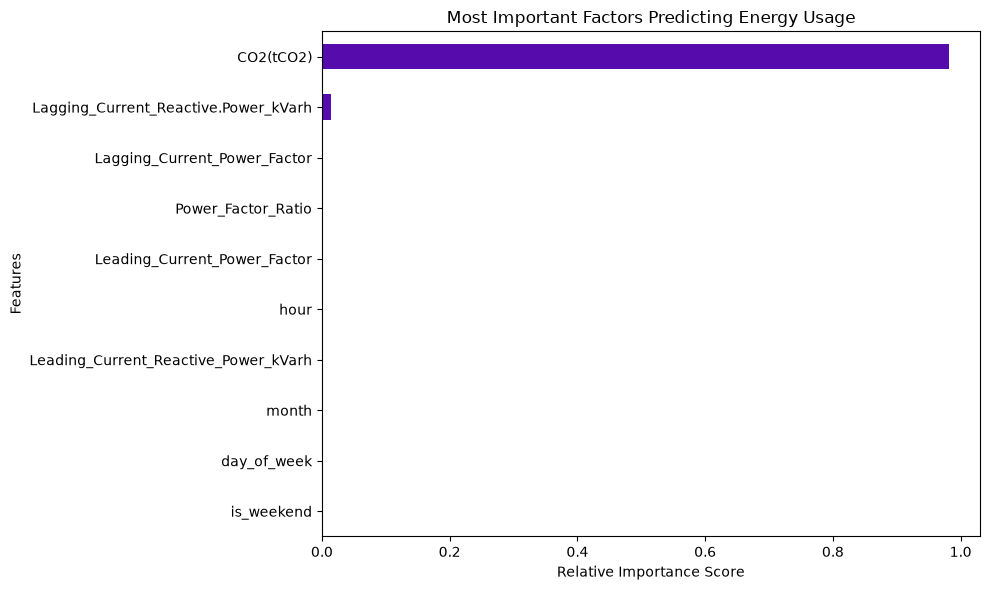

In [9]:
# Check feature importance using your exact model name: dt_model
import pandas as pd
import matplotlib.pyplot as plt

importances = dt_model.feature_importances_
feat_importances = pd.Series(importances, index=features)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='#560bad')
plt.title('Most Important Factors Predicting Energy Usage')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()